In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression

## Importación del dataframe y visualización de algunos datos. Validamos si hay datos null

In [2]:
ruta = "C:/Users/G_Ardila/OneDrive/Desktop/Regresión Lineal/house_prices_dataset.csv"
df = pd.read_csv(ruta)
df.head()

,price,size_m2,bedrooms,age,distance_city_km,income,location,date
0,476018.849341,89.934283,2.0,12.0,0.804341,3752.604161,Centro,2018-01-01 00:00:00
1,309740.810927,77.234714,4.0,12.0,4.156316,1567.680520,Sur,2018-01-01 01:00:00
2,390926.975325,92.953771,2.0,24.0,3.510168,2858.468526,Sur,2018-01-01 02:00:00
3,505833.196199,110.460597,5.0,10.0,NaN,3167.236037,Norte,NaN
4,304383.649820,75.316933,4.0,39.0,2.137373,2036.858417,Norte,2018-01-01 04:00:00


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             95098 non-null  float64
 1   size_m2           95034 non-null  float64
 2   bedrooms          95046 non-null  float64
 3   age               95011 non-null  float64
 4   distance_city_km  95124 non-null  float64
 5   income            94967 non-null  float64
 6   location          95045 non-null  object 
 7   date              94906 non-null  object 
dtypes: float64(6), object(2)
memory usage: 6.1+ MB


In [4]:
df.isnull().sum()

price               4902
size_m2             4966
bedrooms            4954
age                 4989
distance_city_km    4876
income              5033
location            4955
date                5094
dtype: int64

# Limpieza de datos (nulls & tipos)

1. Rellenar nulls de variables numéricas por la mediana por cuanto esta representa el centro real de los datos y es mejor que la media

In [5]:
# reemplazo de nulls en variables numéricas
df["price"] = df["price"].fillna(df["price"].median())
df["size_m2"] = df["size_m2"].fillna(df["size_m2"].median())
df["bedrooms"] = df["bedrooms"].fillna(df["bedrooms"].median())
df["age"] = df["age"].fillna(df["age"].median())
df["income"] = df["income"].fillna(df["income"].median())
df["distance_city_km"] = df["distance_city_km"].fillna(df["distance_city_km"].median())



 2. location, podemos usar la moda para reemplazar los nulls, está es una variable categorica (centro,sur,norte, oriente,occidente), la moda
 representa el valor más común, como los valores null de la data son ~5% esto tendra un impacto menor en la data

In [6]:
# Contamos los null
df['location'].value_counts(dropna=False)

location
Occidente    23875
Norte        23761
Centro       23738
Sur          23671
NaN           4955
Name: count, dtype: int64

mode() devuelve una Serie, incluso si solo hay un valor frecuente. Esto es porque podría haber un "empate" 
(varios valores que se repiten la misma cantidad de veces). Al ser el resultado una Serie, usamos [0] para extraer el primer elemento de esa lista de modas.

In [7]:
# validamos cual es la categoria más frecuente (moda) para realizar el reemplazo de los datos null
df['location'].mode()[0]

'Occidente'

In [8]:
# reemplazamos los nulll de location
df['location'] = df['location'].fillna(df['location'].mode()[0])


para los datos tipo fecha vamos a imputar datos, lo que quiere decir rellenar con las fecha anterior para evitar perder los datos, 
tambien se podría eliminar estos ya que son ~5% y no afectarían tanto el dataset


In [9]:
df['date'] = df['date'].ffill()

In [10]:
# validamos nulls de nuevo para estar seguros
df.isnull().sum()

price               0
size_m2             0
bedrooms            0
age                 0
distance_city_km    0
income              0
location            0
date                0
dtype: int64

Cambiar tipos de datos, si es necesario

In [11]:
#Cambiar el campo de fecha a datetime
df["date"] = pd.to_datetime(df["date"])

In [12]:
# Cambiar de float a int
df["bedrooms"] = df["bedrooms"].astype(int)
df["age"] = df["age"].astype(int)

# Exploración EDA

In [13]:
df.columns

Index(['price', 'size_m2', 'bedrooms', 'age', 'distance_city_km', 'income',
       'location', 'date'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   price             100000 non-null  float64       
 1   size_m2           100000 non-null  float64       
 2   bedrooms          100000 non-null  int64         
 3   age               100000 non-null  int64         
 4   distance_city_km  100000 non-null  float64       
 5   income            100000 non-null  float64       
 6   location          100000 non-null  object        
 7   date              100000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 6.1+ MB


In [15]:
df.describe()

,price,size_m2,bedrooms,age,distance_city_km,income,date
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000
mean,373336.838741,80.048400,2.997440,24.459080,4.899118,3003.922497,2023-09-15 07:26:45.959999744
min,20926.659856,20.000000,1.000000,0.000000,0.000011,800.000000,2018-01-01 00:00:00
25%,322529.266930,67.369479,2.000000,13.000000,1.517954,2492.738564,2020-11-07 15:45:00
50%,373471.709164,80.084702,3.000000,24.000000,3.458103,3006.533790,2023-09-15 07:30:00
75%,424079.045474,92.716453,4.000000,36.000000,6.675084,3508.142214,2026-07-22 23:15:00
max,719250.717703,169.581685,5.000000,49.000000,30.000000,6434.621000,2029-05-29 15:00:00
std,77813.783292,19.495676,1.378184,14.101635,4.794867,778.597689,NaN


In [16]:
df.shape

(100000, 8)

In [17]:
# Cuenta cuántos valores distintos hay en cada columna. Ideal para identificar si una columna es categórica o tiene demasiados valores únicos (como IDs).
df.nunique()

price               95099
size_m2             94909
bedrooms                5
age                    50
distance_city_km    94883
income              94678
location                4
date                94906
dtype: int64

In [18]:
# Nos dice cuántas veces aparece cada valor en la colunma seleccionada
df['location'].value_counts()

location
Occidente    28830
Norte        23761
Centro       23738
Sur          23671
Name: count, dtype: int64

In [19]:
df['bedrooms'].value_counts()

bedrooms
3    23951
2    19116
1    19009
4    18970
5    18954
Name: count, dtype: int64

corr(numeric_only=True)
Esta tabla es una Matriz de Correlación. Nos dice qué tan fuerte es la relación entre dos variables numéricas. Los valores siempre van de -1 a 1.
1.0 (Relación Perfecta Positiva): Si una sube, la otra también. Se ve que la diagonal principal siempre es 1.0 porque cada variable se compara consigo misma.
Cerca de 1.0 (Fuerte): Si una variable aumenta, la otra tiende a aumentar mucho (ej. price y size_m2).
Cerca de -1.0 (Inversa): Si una aumenta, la otra disminuye (ej. price y age).
Cerca de 0 (Nula): No hay una relación clara entre ellas.


In [20]:
df.corr(numeric_only=True)

,price,size_m2,bedrooms,age,distance_city_km,income
price,1.000000,0.717236,0.164856,-0.260724,-0.110599,0.475578
size_m2,0.717236,1.000000,-0.002782,-0.002631,0.003869,0.002340
bedrooms,0.164856,-0.002782,1.000000,0.002400,0.005543,0.001734
age,-0.260724,-0.002631,0.002400,1.000000,0.003493,-0.001040
distance_city_km,-0.110599,0.003869,0.005543,0.003493,1.000000,0.004182
income,0.475578,0.002340,0.001734,-0.001040,0.004182,1.000000


Analizis de correlaciones:
1-price vs size_m2 (0.717): Es la correlación más fuerte. Significa que el tamaño de la casa es el factor que más influye en el precio (a más metros, más caro).
2-price vs income (0.475): Hay una relación moderada. Indica que en zonas con mayores ingresos, los precios tienden a ser más altos.
3-price vs age (-0.260): Correlación negativa débil. Sugiere que, en general, mientras más vieja es la casa (age), el precio tiende a bajar un poco.
4-price vs distance_city_km (-0.110): Relación muy débil. Parece que la distancia a la ciudad no afecta tanto el precio en este dataset específico.

In [21]:
#duplicated(): Recorre el DataFrame fila por fila y marca como True aquellas que son una copia exacta de una fila anterior. 
#Si la fila es "nueva" (la primera vez que aparece), la marca como False.
df.duplicated().sum()

np.int64(0)

# Gráficos exploratorios

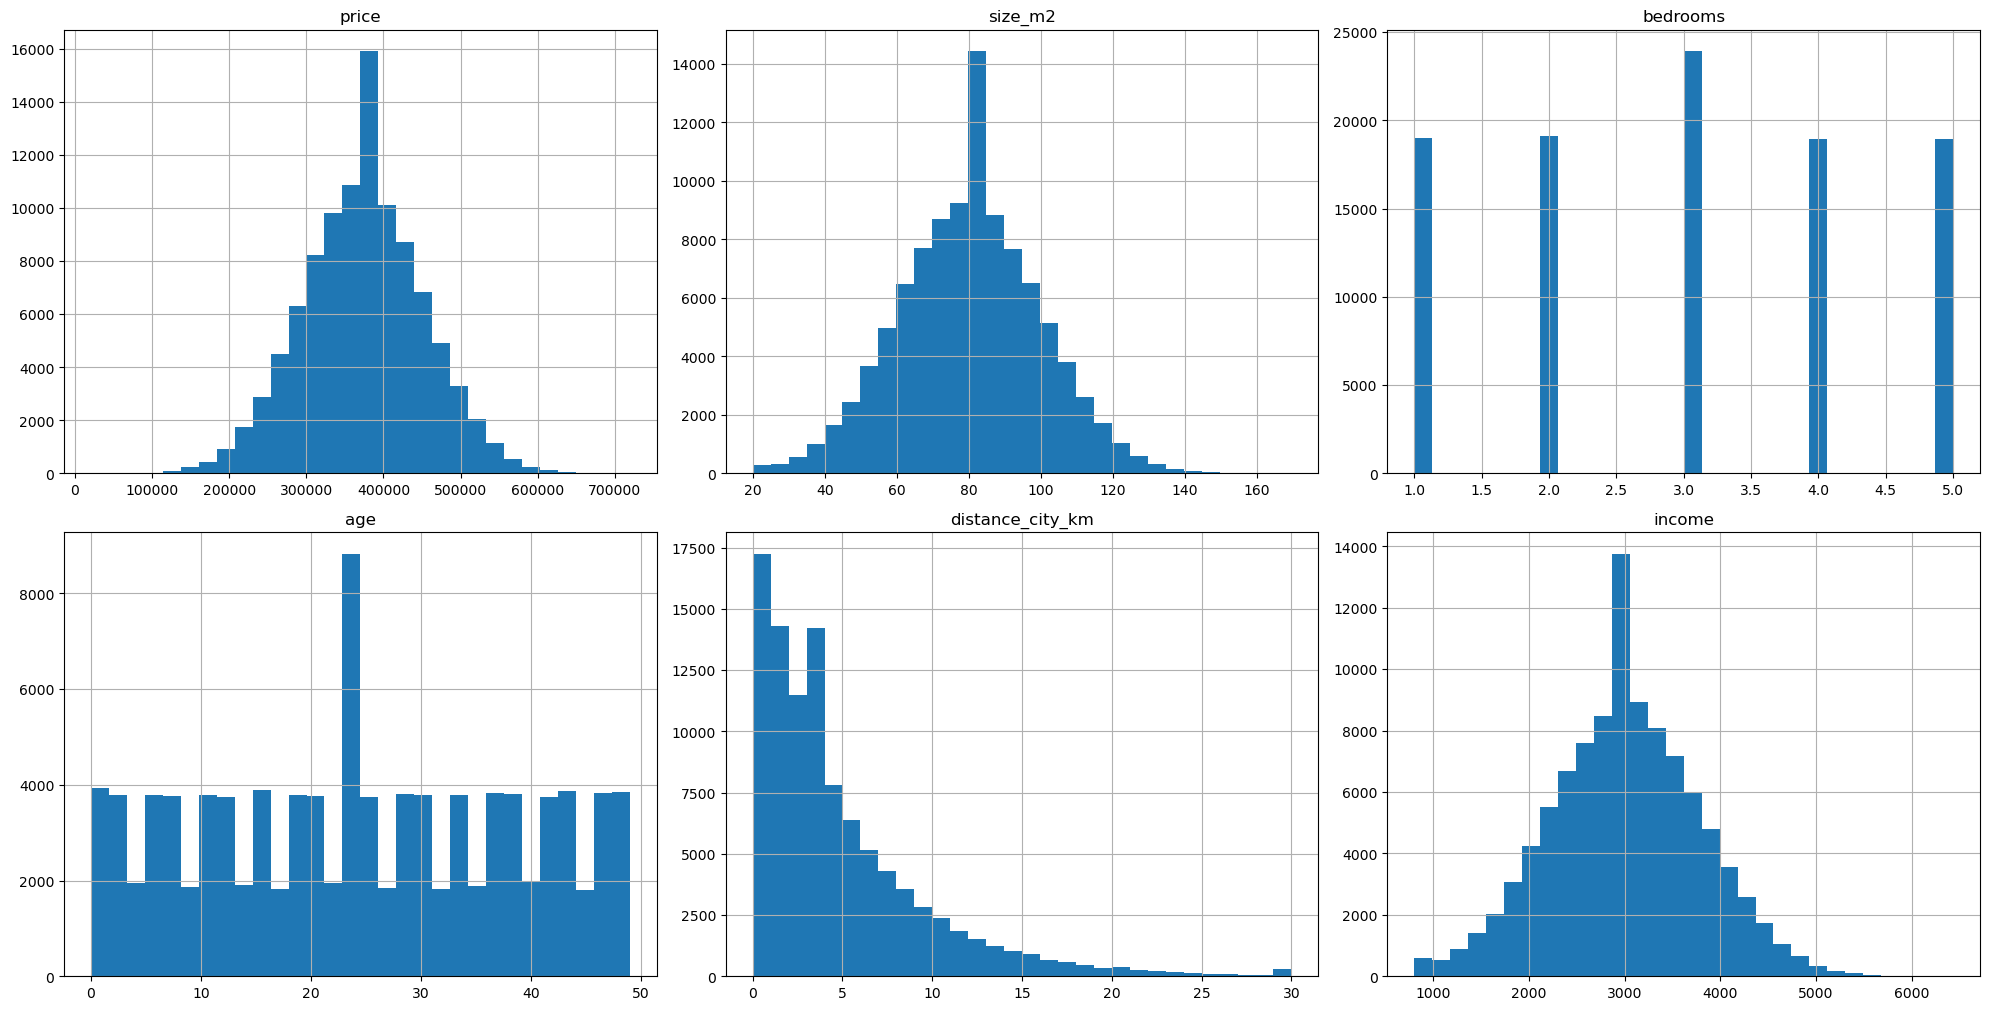

In [22]:
df_graficos_iniciales = df.drop("date",axis = 1)
df_graficos_iniciales.hist(figsize=(20,15),layout=(3, 3), bins=30)
plt.tight_layout()

# Análisis de gráficos iniciales
Eje X (Horizontal): Representa los valores de la columna (el "rango" de datos). Por ejemplo, en price, el eje X muestra cuánto dinero cuestan las casas.Eje Y (Vertical): Representa la frecuencia, es decir, cuántas veces aparece un rango de valores en el dataset (el conteo de filas).

Para entender qué dicen tus datos, nos fíjamos en la forma de las barras:
### price, size_m2 e income: 
Tienen forma de "campana" (Distribución Normal). La mayoría de los datos están en el centro. Por ejemplo, en price, se ve que la barra más alta está cerca de los 400,000; eso significa que la mayoría de las casas valen eso. 
### distance_city_km: 
Tiene una "cola" hacia la derecha (Sesgo positivo). Indica que la gran mayoría de las casas están muy cerca de la ciudad (entre 0 y 5 km), y hay muy poquitas que están lejos (a 20 km).
### bedrooms: 
Se ve "entrecortado" porque son números enteros (2, 3, 4 habitaciones). Las barras nos dicen cuántas casas hay con cada número de cuartos.
### age: 
La distribución presenta un comportamiento casi uniforme, lo que indica una cantidad similar de viviendas a lo largo de las distintas edades. Sin embargo, se observa un pico destacado alrededor de los 25 años, evidenciando una mayor concentración de casas con esa antigüedad dentro del dataset.

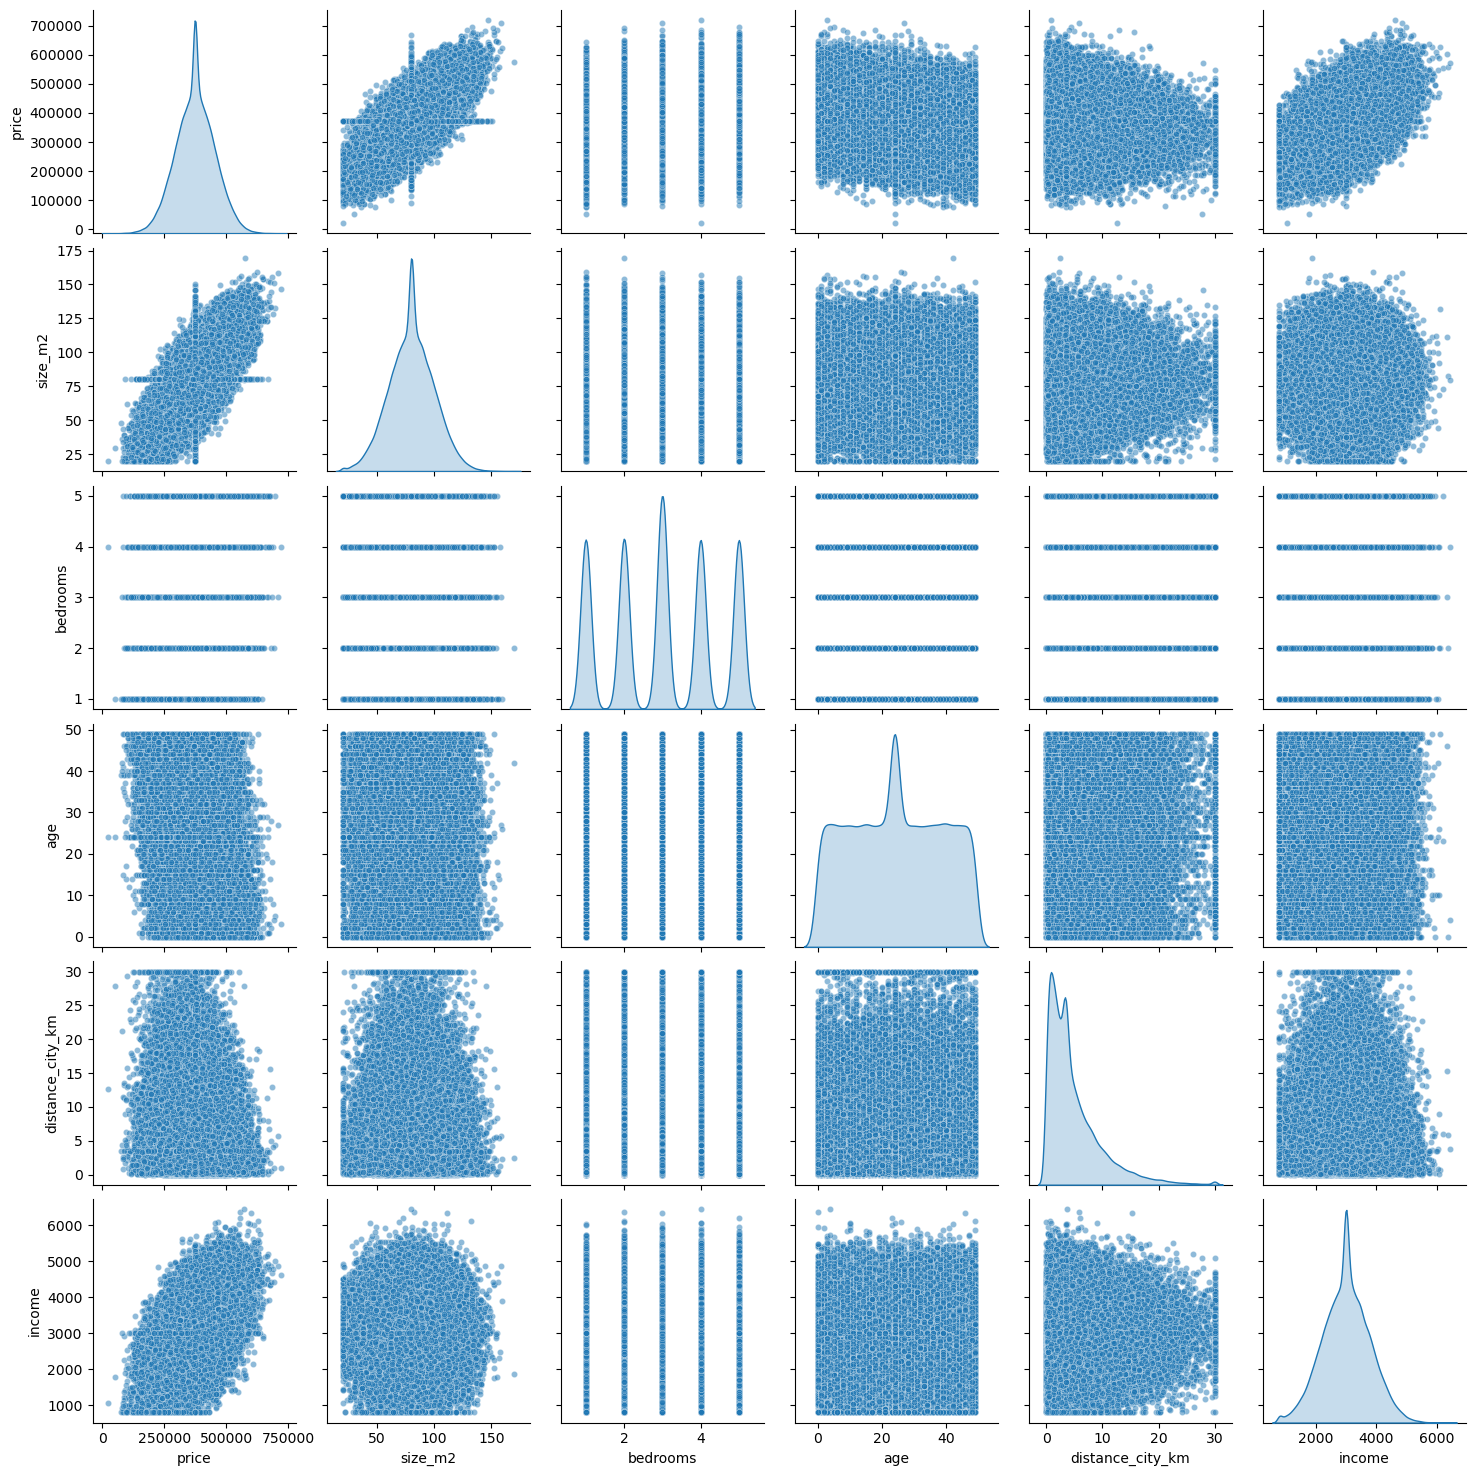

In [23]:
sns.pairplot(
    df.select_dtypes(include='number'), 
    diag_kind='kde',  # Muestra curvas de densidad suaves en la diagonal
    plot_kws={'alpha': 0.5, 's': 20} # Puntos más pequeños y transparentes para ver mejor la densidad
);


## Análisis Detallado de las Relaciones de Datos (Pairplot)
### 1. La Diagonal (Distribución Individual)
Representan cómo se comporta cada variable por sí sola mediante curvas de densidad:Price e Income: Muestran curvas en forma de campana casi perfectas (Distribución Normal). Esto indica que la mayoría de las casas y los ingresos de la zona se concentran en valores promedio, con muy pocos casos extremos.Distance_city_km: Presenta un pico muy alto al inicio que cae abruptamente. Esto confirma que la gran mayoría de las propiedades están muy cerca del centro urbano y la oferta disminuye drásticamente al alejarse.Bedrooms: Se observan varios picos aislados. Es el comportamiento típico de datos discretos: las casas tienen un número exacto de habitaciones (2, 3, 4 o 5), sin valores intermedios.
### 2. Relaciones Fuertes (Nubes Estiradas)
Cuando los puntos forman una "línea" ascendente, existe una conexión directa entre las variables:Price vs Size_m2: Es la relación más dominante del dataset. La nube sube en diagonal de forma clara, lo que significa que el tamaño de la casa es el factor más predecible para determinar su precio.Price vs Income: Muestra una tendencia ascendente. Esto indica que el nivel económico de la zona tiene un impacto positivo directo en el valor de las propiedades.
### 3. Relaciones Inversas (Nubes que Bajan)
Price vs Distance_city_km: La nube es más densa y alta a la izquierda y tiende a bajar hacia la derecha. Esto sugiere que, por lo general, el precio máximo de una propiedad tiende a reducirse conforme aumenta la distancia a la ciudad.
### 4. Sin Relación (Nubes de "Ruido" o Cuadradas)
Age vs Size_m2: Los puntos forman un bloque cuadrado sin una dirección definida. Esto demuestra que la antigüedad de la casa no influye en su tamaño; en este mercado existen casas grandes tanto nuevas como antiguas por igual.
### 5. Variables Discretas (Líneas Verticales)
Relaciones con Bedrooms: Al comparar cualquier variable contra el número de habitaciones, los datos se agrupan en columnas verticales. Esto permite ver que, aunque el precio base sube con más habitaciones, hay mucho solapamiento: una casa de 3 habitaciones puede ser más cara que una de 4 si otros factores (como los metros cuadrados) son superiores.

# Análisis de relación entre variables

(10000.0, 719250.7177030407)

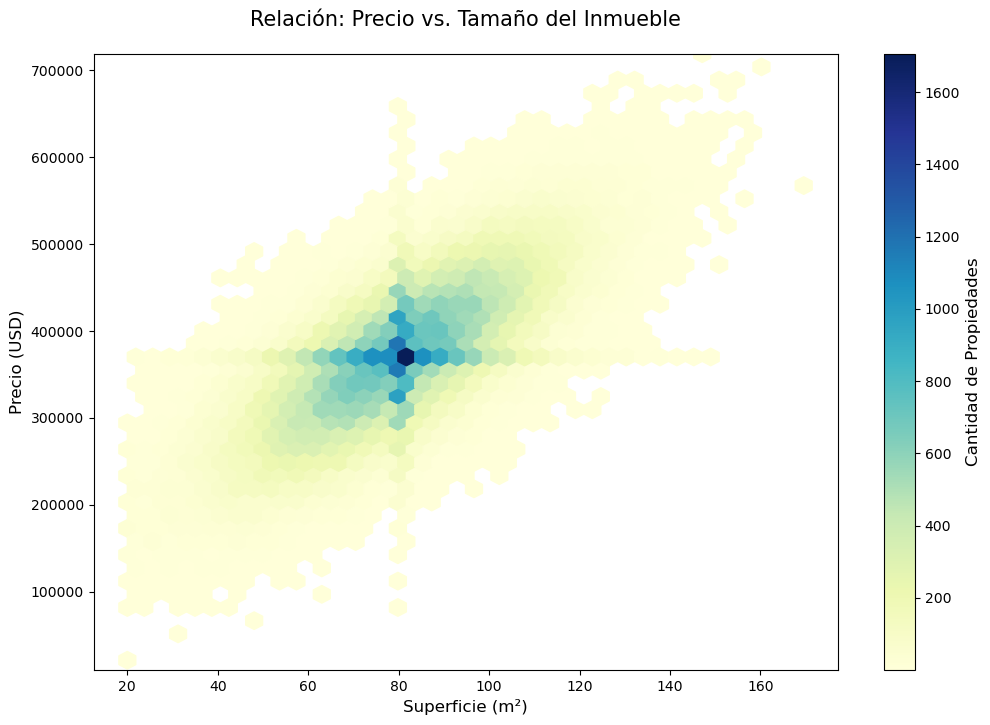

In [37]:
plt.figure(figsize=(12, 8))

# Creamos el gráfico de hexágonos
# gridsize: controla el tamaño de los hexágonos (mayor número = hexágonos más pequeños)
# cmap: 'YlGnBu' (Amarillo-Verde-Azul) es muy claro para ver densidades
hb = plt.hexbin(df['size_m2'], df['price'], 
                gridsize=40, 
                cmap='YlGnBu', 
                mincnt=1) # mincnt=1 evita pintar hexágonos vacíos

# Añadimos la barra de colores para interpretar la densidad
cb = plt.colorbar(hb)
cb.set_label('Cantidad de Propiedades', fontsize=12)

# Etiquetas y títulos claros
plt.title('Relación: Precio vs. Tamaño del Inmueble', fontsize=15, pad=20)
plt.xlabel('Superficie (m²)', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)

# Ajustamos límites si es necesario para evitar los errores de "precio 0"
plt.ylim(10000, df['price'].max()) 

## Relación precio-tamaño
Correlación Directa y Proporcional: Se confirma una relación positiva clara; la superficie construida es el motor principal del precio. La alineación de los núcleos de densidad (zonas más oscuras) dibuja una trayectoria ascendente constante, lo que permite predecir el valor del inmueble con un margen de error reducido basándose exclusivamente en su metraje.Segmento Dominante del Mercado: El gráfico revela una concentración crítica de operaciones (el "Hotspot" o zona de máxima densidad) en propiedades de 80 m². Este fenómeno indica que el mercado está altamente estandarizado, con una oferta masiva de unidades que oscilan entre los 350,000 y 420,000 USD.Eficiencia del Precio por Metro Cuadrado: En el rango de 40 a 100 m², la densidad es muy compacta, lo que sugiere un mercado maduro donde el precio por metro cuadrado es consistente y predecible. Salirse de este rango hacia la derecha (más de 120 m²) muestra una dispersión de colores más claros, indicando que las propiedades grandes son más escasas y sus precios están menos estandarizados.Identificación de Inmuebles fuera de Mercado:Zonas claras superiores: Representan propiedades con un precio "premium" por m², probablemente asociado a acabados de lujo o ubicaciones excepcionales.Zonas claras inferiores: Representan unidades con un precio por m² inusualmente bajo, identificadas como activos infravalorados o con necesidades de remodelación.


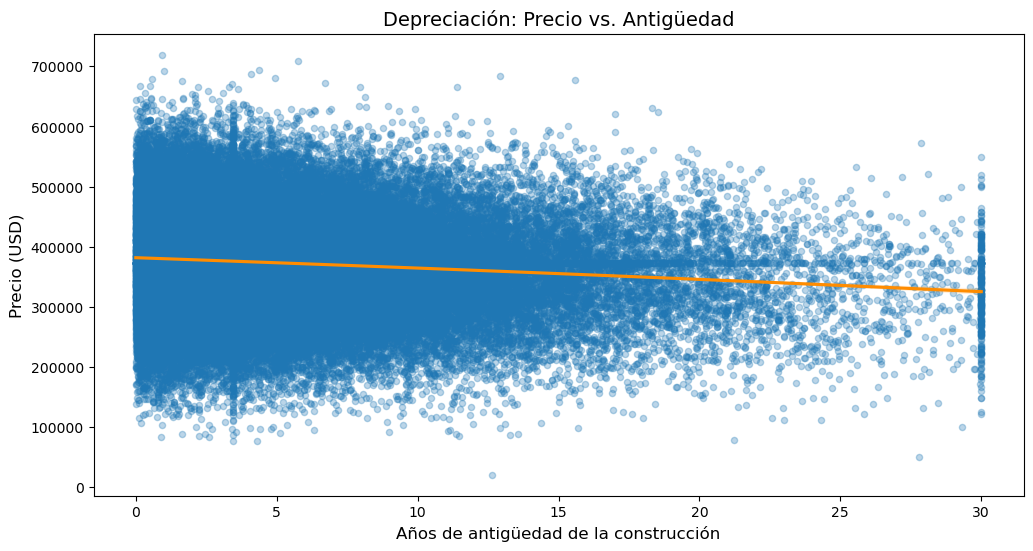

In [28]:
plt.figure(figsize= (12,6))
sns.regplot(data = df, x = "distance_city_km", y = "price",
           scatter_kws={'alpha':0.3, 's':20},
           line_kws={"color":'darkorange'},
           order = 2)
plt.title('Depreciación: Precio vs. Antigüedad', fontsize=14)
plt.xlabel('Años de antigüedad de la construcción', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12);

## Gráfico de Precio vs. Antigüedad. 
1. Tendencia de Depreciación Negativa. La línea naranja muestra una pendiente descendente, lo cual es lógico: a mayor antigüedad, el valor de la construcción tiende a bajar. Sin embargo, hay que fijarse en que la pendiente no es muy pronunciada. Esto sugiere que la ubicación o el valor del suelo mantienen el precio relativamente alto a pesar del paso de los años.
2. Mayor Volatilidad en Construcciones Nuevas. La "nube" de puntos es mucho más gruesa y alta entre los 0 y 10 años. Conclusión: Hay mucha más oferta de vivienda nueva o joven, y sus precios varían enormemente (desde los 100k hasta los 700k USD). En las viviendas nuevas es donde más influyen otros factores como los acabados de lujo o las amenidades.
3. El Efecto "Embudo"A medida que avanzamos hacia los 30 años, la dispersión de precios se reduce (la nube se hace más estrecha). Interpretación: Las propiedades viejas tienden a "sincronizar" su valor hacia la baja. Es más raro encontrar una propiedad de 30 años que mantenga un precio de 700k USD comparado con una nueva.
4. Concentración en el Límite (Año 30). Se observa una línea vertical muy marcada justo en el año 30. Dato importante: Esto suele ser un "tope" en la base de datos. Probablemente todas las casas de 30 años o más fueron etiquetadas simplemente como "30". Esto altera un poco la línea de tendencia al final.

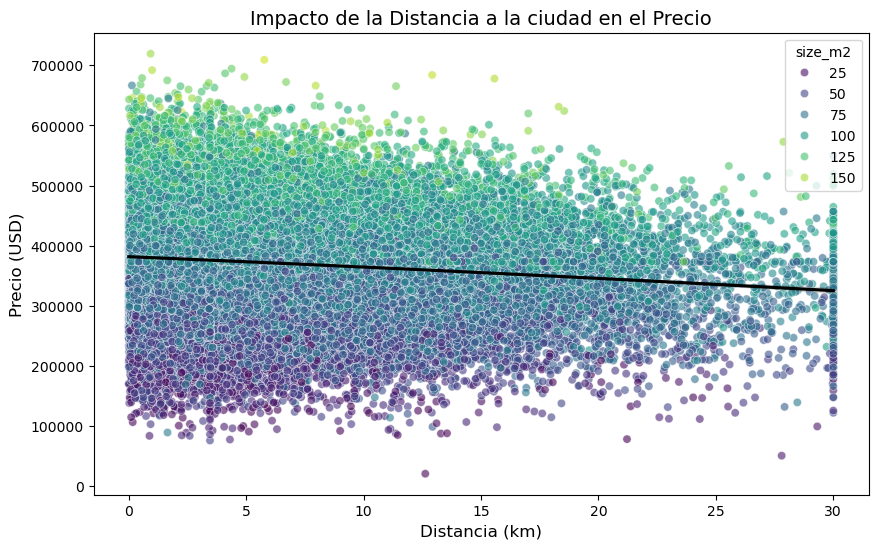

In [29]:
# Usamos size_m2 en el hue porque nos ayuda a ver si los precios altos lejos del centro se deben simplemente a que las casas son mucho más grandes allá,
#o si realmente el suelo es caro
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='distance_city_km', y='price', 
                hue='size_m2', alpha=0.6, palette='viridis')

# Añadir una línea de tendencia suavizada (no necesariamente recta)
sns.regplot(data=df, x='distance_city_km', y='price', 
            scatter=False, color='black', order= 2) 

plt.title('Impacto de la Distancia a la ciudad en el Precio', fontsize=14)
plt.xlabel('Distancia (km)', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12);

## Precio vs. Distancia.
1. La "Prima" por Cercanía (Pendiente Negativa). La línea negra muestra una tendencia descendente clara: a mayor distancia del centro, el precio promedio baja. Sin embargo, la pendiente es suave. Esto significa que la distancia castiga el precio, pero no lo desploma de golpe; hay otros factores sosteniendo el valor en la periferia.
2. El Tamaño (size_m2) domina el Precio. El uso del color es muy revelador aquí: Zonas Amarillas/Verdes (Casas grandes): Se concentran en la parte superior del gráfico. Independientemente de la distancia, si la casa es grande (125-150 m²), su precio se mantiene alto. Zonas Moradas (Casas pequeñas): Se mantienen en la base. Hay que notar que una casa pequeña de 25-50 m² en el centro (0 km) puede costar lo mismo que una casa mediana de 75 m² a los 25 km.
3. Descentralización de las Casas Grandes. Se observa que en la densidad de los puntos amarillos y verdes claros hay una presencia masiva de casas grandes incluso a los 20-30 km. Interpretación: El mercado ofrece "más metros por el dinero" a medida que se alejan. Mucha gente parece aceptar vivir lejos a cambio de una casa de mayor tamaño, lo que genera esa mezcla de colores en distancias lejanas.
4. Mayor Incertidumbre en el Centro. Cerca del km 0, la dispersión vertical de precios es máxima (va desde los 100k hasta los 700k USD).A medida que se alejan (km 25-30), la "nube" se vuelve un poco más compacta. El centro es más impredecible porque conviven departamentos pequeños de lujo con propiedades viejas o deterioradas.
5. En el km 30, hay una línea vertical perfecta. Al igual que con la antigüedad, esto indica que los datos fueron "agrupados": cualquier propiedad a más de 30 km fue registrada exactamente como "30 km".

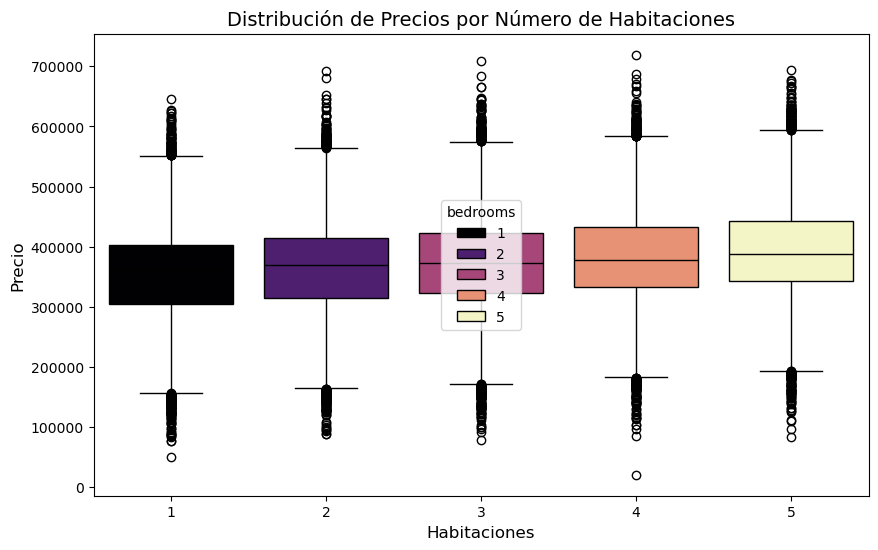

In [30]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='bedrooms', y='price', palette='magma', hue= 'bedrooms')

plt.title('Distribución de Precios por Número de Habitaciones', fontsize=14)
plt.xlabel('Habitaciones', fontsize=12)
plt.ylabel('Precio', fontsize=12);

## Relación entre el precio y la cantidad de habitaciones.
1. Tendencia al alza, pero moderada. Existe un incremento en el precio mediano (la línea negra dentro de cada caja) a medida que aumentan las habitaciones. Sin embargo, el salto no es tan drástico como en los metros cuadrados. Esto sugiere que añadir una habitación no duplica el valor, sino que le da un empujón incremental.
2. Solapamiento masivo (Rango de Precios). Lo más llamativo es que las cajas se enciman casi por completo. Conclusión: Un departamento de 1 habitación de "lujo" puede costar lo mismo o incluso más que una casa de 5 habitaciones en una zona más económica. El número de habitaciones, por sí solo, no define el segmento de precio del inmueble.
3. Presencia constante de "Outliers" (Valores atípicos). Todas las categorías tienen muchos puntos negros arriba de los 600,000 USD. Esto indica que existen propiedades "premium" en todos los niveles. Hay departamentos de 1 habitación sumamente caros (posiblemente en zonas exclusivas) que rompen la regla del promedio.
4. Consistencia en la Variabilidad. El tamaño de las cajas (el Rango Intercuartílico) es bastante similar en todas las columnas. Esto significa que la incertidumbre de precio es la misma si buscas una casa de 2 o de 5 habitaciones; la dispersión del mercado es constante.

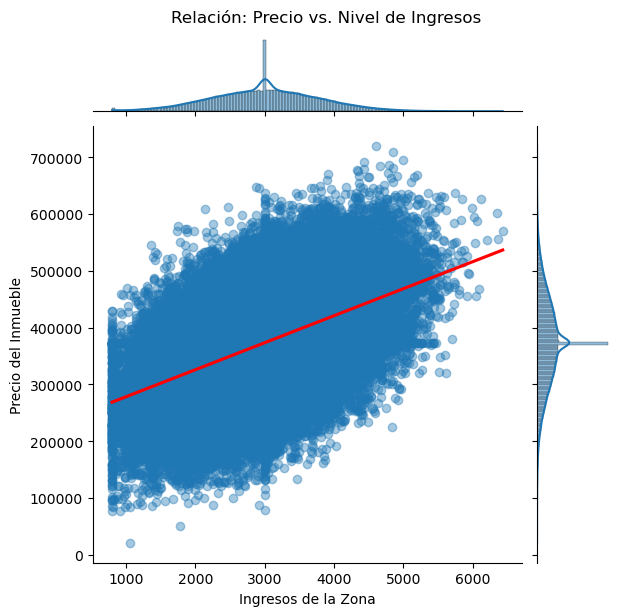

In [31]:
# Un gráfico 2 en 1: Dispersión + Distribución
g = sns.jointplot(data=df, x='income', y='price', kind='reg', 
                  scatter_kws={'alpha':0.4}, line_kws={'color':'red'})

g.fig.suptitle('Relación: Precio vs. Nivel de Ingresos', y=1.02)
g.set_axis_labels('Ingresos de la Zona', 'Precio del Inmueble');

## Precio vs nivel de ingresos
1. Correlación muy fuerte y positiva. De todas las variables que hemos visto, los Ingresos de la Zona parecen ser el predictor más sólido del precio. La línea roja sube de forma muy constante: si el ingreso de la zona sube, el precio del inmueble sube de manera casi garantizada.
2. Distribución acampanada (Normal). A diferencia de la distancia o la antigüedad, tanto los ingresos como los precios siguen una curva de campana casi perfecta.La mayoría de las zonas ganan entre 2,000 y 4,000 unidades.Es muy raro encontrar zonas de ingresos bajísimos (menos de 1,000) o altísimos (más de 6,000), lo que hace que los extremos del gráfico tengan menos puntos (menos "ruido").
3. Estabilidad del Mercado. A diferencia del gráfico de metros cuadrados (donde había mucha dispersión vertical), aquí la nube de puntos es más "compacta" alrededor de la línea. Conclusión: El nivel de ingresos de la zona pone un "suelo" y un "techo" bastante claros al precio. Es difícil encontrar una casa barata en una zona de ingresos altos, algo que sí pasaba con los metros cuadrados o la antigüedad.

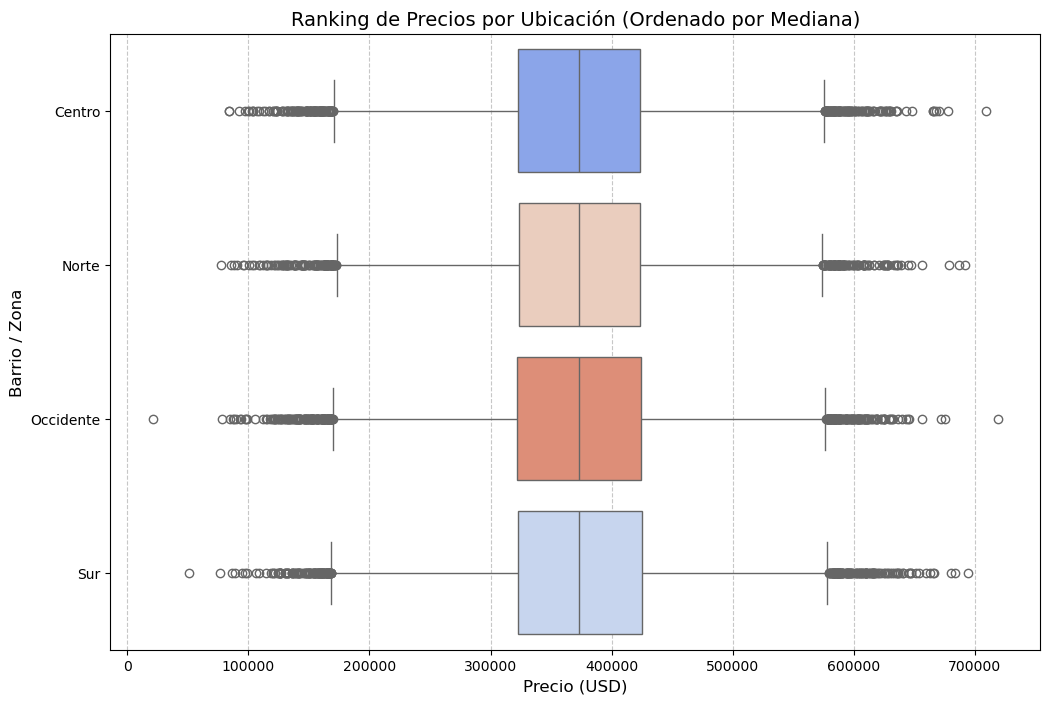

In [39]:

# 1. Calcular el orden de los barrios por precio promedio (esto es clave)
orden_barrios = df.groupby('location')['price'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 8))

# 2. Usar un Boxplot para ver no solo el promedio, sino el rango de cada zona
sns.boxplot(data=df, y='location', x='price', order=orden_barrios, palette='coolwarm', hue = 'location', legend=False)

plt.title('Ranking de Precios por Ubicación (Ordenado por Mediana)', fontsize=14)
plt.xlabel('Precio (USD)', fontsize=12)
plt.ylabel('Barrio / Zona', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.7);


## Ranking de precios por ubicación
1. Mercado Homogéneo entre Zonas. Las medianas son casi iguales (todas rondan los 380,000 USD). Conclusión: La ubicación general (Norte, Sur, Centro, Occidente) no parece ser el factor que define el precio "base". Es un mercado muy equilibrado donde el precio medio no cambia drásticamente por mudarce de una zona a otra.
2. Dispersión y Rango (Cajas y Bigotes). El tamaño de las cajas y la longitud de los "bigotes" son prácticamente simétricos en las cuatro zonas. Esto indica que la variabilidad de precios es constante. En cualquier zona que se elija, se encontrará el mismo abanico de opciones: desde lo más económico (aprox. 180k) hasta lo más caro (aprox. 580k) dentro del rango normal.
3. Análisis de Valores Atípicos (Outliers). Centro y Sur: Tienen los puntos más extremos hacia la derecha (cerca de los 700,000 USD). Esto sugiere que, aunque el promedio es igual, las propiedades de lujo extremo o más exclusivas se están concentrando ligeramente más en el Centro y el Sur. Occidente y Sur: Tienen valores atípicos hacia la izquierda (precios muy bajos, cerca de 0).
4. El "Vacío" de Datos. Se observa que hay un espacio vacío de puntos entre los 200,000 y 300,000 USD (donde están los bigotes izquierdos). Interpretación: Parece haber un salto de calidad o de tipo de inmueble. O compras algo muy económico (puntos a la izquierda) o saltas directamente al grueso del mercado (la caja). No hay mucha oferta en el "rango medio-bajo".
5. Sesgo de Datos. Las cajas están ligeramente desplazadas hacia la derecha respecto al centro del gráfico total.Esto significa que el mercado tiene un sesgo positivo: hay más variedad de precios altos que de precios bajos.


# Análisis Integral del Mercado Inmobiliario.

El presente análisis evalúa la relación entre el Precio de las propiedades y sus principales variables determinantes (Superficie, Ubicación, Antigüedad e Ingresos). A continuación, se detallan las conclusiones obtenidas mediante la visualización avanzada de datos:

## 1. Determinantes Críticos del PrecioSuperficie (m²): 
Se confirma como el predictor más robusto. El análisis de densidad (Hexbin) revela que el "corazón del mercado" se concentra en unidades de 80 m², con un precio promedio de $380,000 USD. Existe una estandarización masiva en este segmento, lo que sugiere una oferta dominante de tipologías específicas (ej. departamentos de 2-3 habitaciones).Nivel de Ingresos (Income): Existe una correlación positiva casi perfecta entre el nivel socioeconómico de la zona y el valor de la propiedad. Esta variable actúa como un "suelo" de valor, reduciendo la volatilidad del precio a medida que el ingreso por zona aumenta.
## 2. Comportamiento Geográfico y de UbicaciónHomogeneidad Zonal: 
Sorprendentemente, la mediana de precios es constante entre las zonas Norte, Sur, Centro y Occidente. Esto indica que el mercado está equilibrado geográficamente y que la ubicación macro (zona) pesa menos que los atributos específicos del inmueble o el micro-entorno (ingresos de la manzana).Distancia al Centro: Se observa una depreciación moderada por distancia. Sin embargo, el tamaño de la propiedad compensa este factor: en la periferia se encuentran inmuebles de mayor metraje que mantienen precios competitivos frente a unidades pequeñas céntricas.
## 3. Atributos Físicos y Depreciación
Antigüedad: El mercado muestra una curva de depreciación estándar, donde las unidades nuevas (0-10 años) presentan la mayor variabilidad de precios y volumen de oferta. A partir de los 30 años, los valores tienden a estabilizarse en un piso de precio definido por el valor del suelo.
Habitaciones: El número de dormitorios muestra una correlación incremental con el precio, aunque con un alto grado de solapamiento. Esto sugiere que el mercado valora más los metros cuadrados totales que la división interna de los mismos.

# Modelo de regresión lineal

In [44]:
# Normalizamos los datos usando standar scaler

scaler = StandardScaler()
cols_to_scale = ["size_m2", "income", "distance_city_km", "age"]
normado  = scaler.fit_transform(df[cols_to_scale])
df_normado = pd.DataFrame(data = normado, columns= cols_to_scale)
df_normado["bedrooms"] = df["bedrooms"]
df_normado["location"] = df["location"]
df_normado["date"] = df["date"]
df_normado["price"] = df["price"]



In [48]:
# Variables dependientes e independientes
X = df_normado.drop(["bedrooms","location", "date", "price" ], axis  = 1)
y = df_normado["price"]

# Hacemos split de los datos en grupos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.8, random_state = 42)




In [51]:
# Crear y enternar el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [52]:
# Realizar predicciones usando el conjunto de de prueba
predicciones_lineal = modelo.predict(X_test)

In [56]:
# Revisamos el porcentaje de acierto del modelo, en este caso es un 82.35%
modelo.score(X_test, y_test)

0.8235757164652926

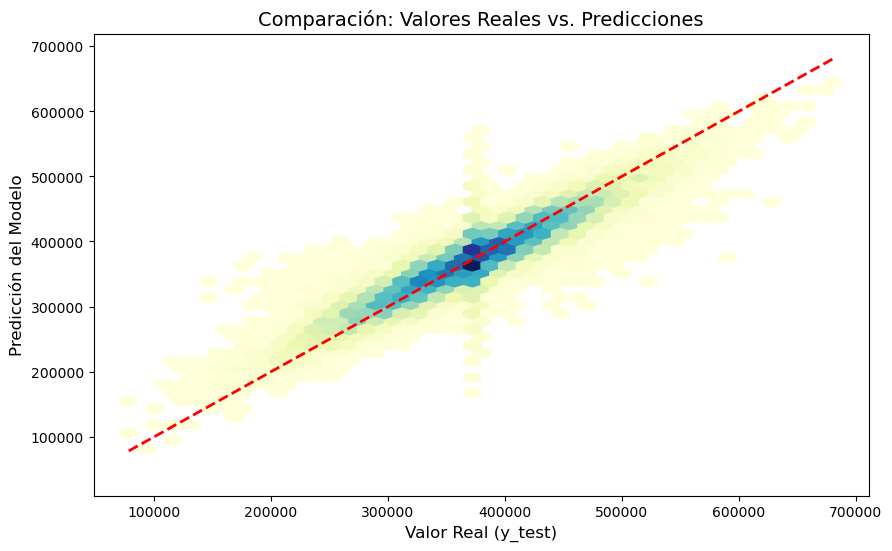

In [58]:
# Gráfico de Dispersión: Cuanto más cerca estén los puntos de la línea, mejor es el modelo.
plt.figure(figsize = (10,6))

# Dibujamos los puntos
hb = plt.hexbin(x=y_test, y=predicciones_lineal, 
                gridsize=40, 
                cmap='YlGnBu', 
                mincnt=1) # mincnt=1 evita pintar hexágonos vacíos

# Ajustamos límites si es necesario para evitar los errores de "precio 0"
plt.ylim(10000, df_normado['price'].max());

# Divujamos la línea de referencia
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], color ="red", lw=2, linestyle="--")
plt.title('Comparación: Valores Reales vs. Predicciones', fontsize=14)
plt.xlabel('Valor Real (y_test)', fontsize=12)
plt.ylabel('Predicción del Modelo', fontsize=12)



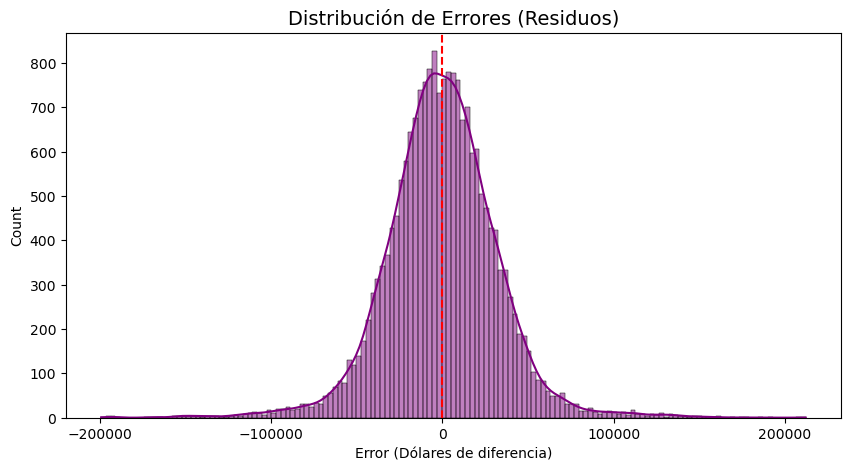

In [59]:
# Los residuos son la resta entre lo real y lo predicho
residuos = y_test - predicciones_lineal

plt.figure(figsize=(10, 5))
sns.histplot(residuos, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribución de Errores (Residuos)', fontsize=14)
plt.xlabel('Error (Dólares de diferencia)');

Si el gráfico de residuos tiene forma de campana centrada en cero el modelo es insesgado y confiable

In [68]:
# Creamos data de prueba para probar el modelo


# Creamos un diccionario con los datos "crudos"
nuevas_propiedades = pd.DataFrame({
    "size_m2": [84, 150],
    "income": [3000, 3500],
    "distance_city_km": [3, 19],
    "age": [22, 6]
})

# 1. Normalizar los datos nuevos usando el scaler que ya tenías
nuevas_prop_normadas = scaler.transform(nuevas_propiedades)

# 2. Convertir a DataFrame para que mantenga el formato
X_nuevo = pd.DataFrame(nuevas_prop_normadas, columns=cols_to_scale)

# 3. Hacer la predicción
prediccion_final = modelo.predict(X_nuevo)

# Mostrar resultados
for i, precio in enumerate(prediccion_final):
    print(f"Propiedad {i+1}: Precio estimado de ${precio:,.2f} USD")


Propiedad 1: Precio estimado de $391,499.41 USD
Propiedad 2: Precio estimado de $596,705.51 USD


In [69]:
# probamos los resultados obtenidos

# Características de la propiedad que queremos comparar
target_m2 = 84
target_income = 3000
target_dist = 3
target_age = 22

# Definimos un margen de tolerancia (ej. +/- 10% en m2 y 1km en distancia)
margen_m2 = 5
margen_dist = 2

# Filtramos propiedades similares
similares = df[
    (df['size_m2'].between(target_m2 - margen_m2, target_m2 + margen_m2)) &
    (df['distance_city_km'].between(target_dist - margen_dist, target_dist + margen_dist))
]

# Mostramos las 5 más parecidas y su precio real
print(f"Precio predicho por el modelo: ${prediccion_final[0]:,.2f}")
print("\nPropiedades similares encontradas en el dataset:")
print(similares[['size_m2', 'distance_city_km', 'income', 'age', 'price']].head())



Precio predicho por el modelo: $391,499.41

Propiedades similares encontradas en el dataset:
      size_m2  distance_city_km       income  age          price
12  84.839245          2.005987  3260.977656   25  373471.709164
17  86.284947          1.617416  3916.814303   24  437611.497741
27  87.513960          1.437792  2613.180692   29  344304.101957
39  83.937225          3.458103  3006.533790   22  319527.860062
48  86.872366          2.607718  3106.978868   32  392648.399549


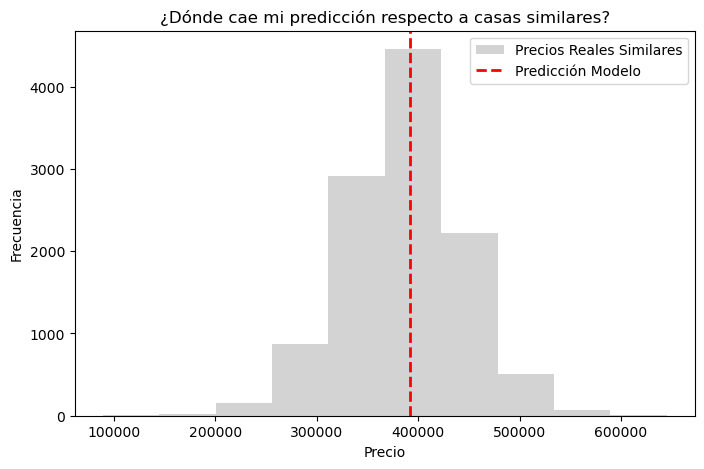

In [70]:
#Comparación Benchmark
plt.figure(figsize=(8, 5))
# Precios de las casas similares
plt.hist(similares['price'], bins=10, color='lightgray', label='Precios Reales Similares')

# Tu predicción como una línea roja
plt.axvline(prediccion_final[0], color='red', linestyle='--', linewidth=2, label='Predicción Modelo')

plt.title('¿Dónde cae mi predicción respecto a casas similares?')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.legend();